In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from daemon_analysis_tools.io.csv_handler import load_and_process_csv
from daemon_analysis_tools.io.yaml_handler import save_answers_to_yaml, load_answers_from_yaml

Load and process data:
- Group answers by publisher and journal, trying to uniform names written in slightly different ways.
- Store in a DataFrame

In [8]:
grouped_questions = load_answers_from_yaml('../../data/processed/all_answers')

False ['Research Data Policy (RDP) exists.'] 1
False ['Research Data Policy (RDP) exists.'] 1
False ['Research Data Policy (RDP) exists.'] 1
No discrepancies detected.
False ['Data sharing encouraged but optional.'] 1
False ['Data sharing encouraged but optional.'] 1
False ['Data sharing encouraged but optional.'] 1
No discrepancies detected.
False ['Public data sharing on a FAIR repository not mentioned in RDP.'] 1
False ['Public data sharing on a FAIR repository not mentioned in RDP.'] 1
False ['Public data sharing on a FAIR repository not mentioned in RDP.'] 1
No discrepancies detected.
False ['Mentioned in the RDP but optional.'] 1
False ['Mentioned in the RDP but optional.'] 1
False ['Mentioned in the RDP but optional.'] 1
No discrepancies detected.
False ['No mention of DOIs or other persistent identifiers for datasets or codes.'] 1
False ['No mention of DOIs or other persistent identifiers for datasets or codes.'] 1
False ['No mention of DOIs or other persistent identifiers for 

In [9]:
tags_lookup = {"language understanding" : "Comprehension",
               "Language understanding" : "Comprehension",
               "difficulty in matching information and question" : "Comprehension",
               "Difficulty in matching information and question" : "Comprehension",
               "Selected answer is better interpretation of RDP." : "Comprehension",
               "Text missing and language understanding" : "Comprehension",
               "Text missing and Language understanding" : "Comprehension",
               "Text missing and  language understanding" : "Comprehension",
               "Text not found" : "Missed text",
               "Missed text." : "Missed text",
               "Text missing" : "Missed text",
               "Formatting inconsistent" : "Formatting",
               "Same answer but different wording." : "Formatting",
               "Inconsistent formatting." : "Formatting",
               None : "Consistent"}

inconsitencies_dict = {}

for publisher, journals in grouped_questions.items():
    n_question = 0
    inconsitencies = {"Consistent": 0}

    for journal, data in journals.items():
        for question, answer in data.items():
            n_question += 1

            if not answer.has_multiple_answers():
                continue

            if answer.has_discrepancies():
                discrepancy_reason = answer.discrepancy_reason

                if discrepancy_reason in tags_lookup:
                    discrepancy_reason = tags_lookup[discrepancy_reason] 

                if not discrepancy_reason in inconsitencies:
                    inconsitencies[discrepancy_reason] = 0
                
                inconsitencies[discrepancy_reason] += 1
            else:
                inconsitencies["Consistent"] += 1
    
    print(publisher, inconsitencies)
    inconsitencies_dict[publisher] = inconsitencies

False ['Research Data Policy (RDP) exists.', 'Research Data Policy (RDP) exists.'] 1
False ['Data sharing encouraged but optional.', 'Data sharing encouraged but optional.'] 1
False ['Mentioned in the RDP but optional.', 'Mentioned in the RDP but optional.'] 1
False ['Data sharing policy not mentioned in refereeing guidelines.', 'Data sharing policy not mentioned in refereeing guidelines.'] 1
False ['Code sharing not mentioned.', 'Code sharing not mentioned.'] 1
False ['No mention of dependencies for research code.', 'No mention of dependencies for research code.'] 1
False ['No mention of a persistent identifier or specifying a version of developed code.', 'No mention of a persistent identifier or specifying a version of developed code.'] 1
False ['The journal policies do not mention any code quality standards.', 'The journal policies do not mention any code quality standards.'] 1
False ['No mention of automatic testing to verify code functionality.', 'No mention of automatic testing t

Get a `dict` labeled by publisher names of `dict`s labeled by journal names of `dict`s of `Question` instances. The `.answer` attribute contains the answers given by the respondents and the explanations text to motivate it.

[156  59  11] ['Consistent', 'Missed text', 'Comprehension']
[215  16   7] ['Consistent', 'Comprehension', 'Missed text']
[205   4] ['Consistent', 'Comprehension']
[90 18  6] ['Consistent', 'Comprehension', 'Missed text']
[102  12  19] ['Consistent', 'Missed text', 'Comprehension']
[63 56] ['Consistent', 'Comprehension']
[255  30] ['Consistent', 'Missed text']
[139  14] ['Consistent', 'Comprehension']
[140 114  30] ['Consistent', 'Comprehension', 'Missed text']
[85 10] ['Consistent', 'Comprehension']
[115  29  27] ['Consistent', 'Comprehension', 'Missed text']
[105  25  41] ['Consistent', 'Comprehension', 'Missed text']
[120  50   1] ['Consistent', 'Missed text', 'Rejected insider information']
[257  28] ['Consistent', 'Comprehension']
[118  75  92] ['Consistent', 'Missed text', 'Comprehension']


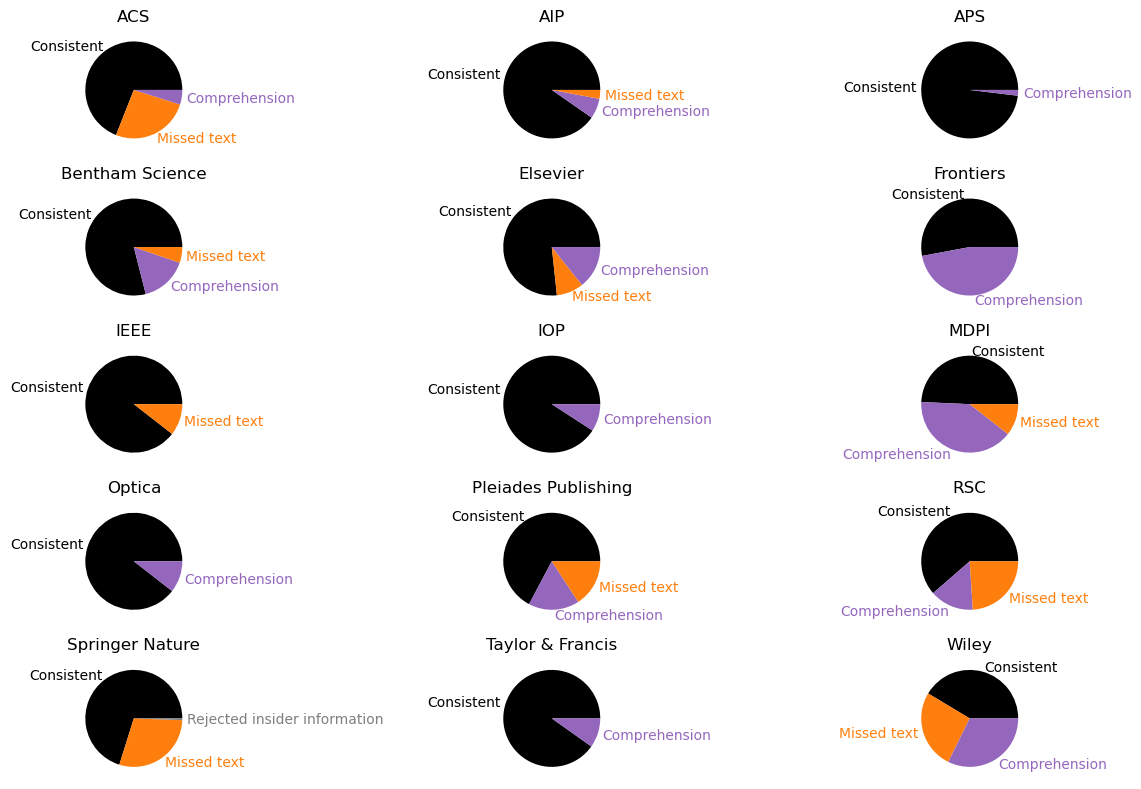

In [10]:
import numpy as np
from copy import deepcopy
from matplotlib import pyplot as plt

color_dict = {"Consistent" : "k",
          "Missed text" : "C1",
          "Comprehension" : "C4",
          "Rejected insider information" : "C7",

}

fig = plt.figure(figsize=(12, 8))

for ind, (publisher, data_0) in enumerate(inconsitencies_dict.items()):
    data = deepcopy(data_0)

    if "Formatting" in data:
        data["Consistent"] += data["Formatting"]
        data.pop("Formatting", None)

    y = np.array(list(data.values()))
    labels = list(data.keys())

    print(y, labels)

    w = 3
    h = int(np.ceil(len(inconsitencies_dict)/w))

    colors = []
    for l in labels:
        colors.append(color_dict[l])

    plt.subplot(h, w, ind+1)
    plt.title(publisher)
    _, texts = plt.pie(y, labels=labels, colors=colors)

    for text, color in zip(texts, colors):
        text.set_color(color)

plt.tight_layout()
fig.savefig("../../data/processed/inconsistencies.pdf")